# FIJI Processing

This notebook enables you to run the FIJI macro through Python.
(Note you can do the manual correcting steps directly or in FIJI)

In [1]:
# We use the library pymeshlab for mesh processing  
import tifffile as tf
import cv2
import pymeshlab
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from skimage.morphology import binary_erosion, convex_hull_image, area_opening
from skimage.transform import downscale_local_mean
from skimage import io, transform
#import trimesh
import os
from tkinter import filedialog
from pathlib import Path
import imagej
#import xarray

In [3]:
# ============== Setup ==============
# Set the resolution of the image stack -- this is from the microscope! 
xy_resolution = 1.625 # <--- To modify
z_resolution = 3 # <--- To modify
FIJI_PATH = r"C:\Users\EQS01\Documents\fiji-stable-win64-jdk\Fiji.app" # <--- To modify

In [4]:
# Initialize FIJI 
# ij = imagej.init('sc.fiji:fiji', mode='interactive')
ij = imagej.init(FIJI_PATH, mode='interactive')
# ij = imagej.init('sc.fiji:fiji+net.imagej:imagej+net.imglib2:imglib2+sc.fiji:fiji+org.morphonlibj:MorphoLibJ_:1.6.3', mode='interactive')
print(f"ImageJ2 version: {ij.getVersion()}")

ImageJ2 version: 2.16.0/1.54p


In [5]:
# Load the .tif file with the path 
file_path = filedialog.askopenfilename(initialdir = os.sep,title = "Select input TIF file", filetypes = (("TIFF Files","*.tif"),("all files","*.*")))
output_folder = Path(file_path).parent # Output folder for all images

# load image
img_stack = tf.imread(file_path) # xarray.DataArray (Python)
#dataset = ij.io().open(file_path) # ImageJ image (Java)
dataset = ij.IJ.openImage(file_path) # ImageJ image (Java)

#Load the .obj file with the path 
#obj_file = filedialog.askopenfilename(initialdir = os.sep,title = "Select file", filetypes = (("Wavefront OBJ","*.obj"),("all files","*.*")))

In [6]:
# Image infos
def dump_info(image):
    """A handy function to print details of an image object."""
    name = image.name if hasattr(image, 'name') else None # xarray
    if name is None and hasattr(image, 'getName'): name = image.getName() # Dataset
    if name is None and hasattr(image, 'getTitle'): name = image.getTitle() # ImagePlus
    print(f" name: {name or 'N/A'}")
    print(f" type: {type(image)}")
    print(f"dtype: {image.dtype if hasattr(image, 'dtype') else 'N/A'}")
    print(f"shape: {image.shape}")
    print(f" dims: {image.dims if hasattr(image, 'dims') else 'N/A'}")

dump_info(dataset)

 name: EH3669P5o6-LW_SOX2.tif
 type: <java class 'ij.ImagePlus'>
dtype: N/A
shape: (1055, 1138, 383)
 dims: ('X', 'Y', 'Z')


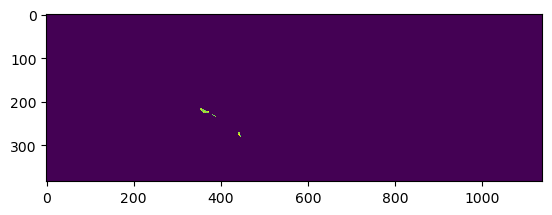

In [7]:
# Show a single slice of yhe image
middle_slice = dataset.shape[2] / 2 # image middle slice

ij.py.show(img_stack[:,:,int(middle_slice)])

In [8]:
# Read FIJI Macro
macro_path = filedialog.askopenfilename(initialdir = os.sep,title = "Select FIJI macro file", filetypes = (("Macro Files","*.ijm"),("all files","*.*")))
macro_file = open(macro_path, "r")
macro_text = macro_file.read()   # ← ajoute cette ligne
macro_file.close() 

lines = macro_text.splitlines()
macro_text = '\n'.join(lines[5:])


add = """
#@ String img_path
#@output Object image_title
#@output Object image_dir

image_dir  = File.getParent(img_path)  + File.separator; 
image_title = File.getName(img_path); 
run("Bio-Formats Importer", "open=[" + image_dir + image_title +"] color_mode=Default rois_import=[ROI manager] view=Hyperstack stack_order=XYCZT");	


"""
macro_text = add + macro_text
#print(macro_file)

In [9]:
# Launch FIJI Macro
args = {
    'img_path': file_path
}

result = ij.py.run_macro(macro_text, args)

[java.lang.Enum.toString] Reading IFDs
[java.lang.Enum.toString] Populating metadata
[java.lang.Enum.toString] Checking comment style
[java.lang.Enum.toString] Populating OME metadata
[java.lang.Enum.toString] Reading IFDs
[java.lang.Enum.toString] Populating metadata
[java.lang.Enum.toString] Checking comment style
[java.lang.Enum.toString] Populating OME metadata


In [ ]:
# Print Output
print(result.getOutput('image_dir'))
print(result.getOutput('image_title'))

* Output image name : **pyimagej.ome.tif**

Can continue the **manual correction on FIJI if needed**